In [141]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

In [183]:
df = pd.read_csv("Scores.csv",sep=";", index_col=0)

In [184]:
df.head(5)

,student_id,gender,parental.level.of.education,subject,score
1,id_001,female,high school,math,23
2,id_001,female,high school,language,40
3,id_002,female,high school,math,68
4,id_002,female,high school,language,"80,5"
5,id_003,male,high school,math,82


In [185]:
df.shape

(972, 5)

In [186]:
df.dtypes

student_id                     str
gender                         str
parental.level.of.education    str
subject                        str
score                          str
dtype: object

In [187]:
id = np.array(df.student_id.unique())
id.shape

(486,)

In [194]:
df2 = pd.DataFrame()

In [195]:
hot_gender = pd.get_dummies(df["gender"], dtype='int')
df2 = pd.concat([df,hot_gender],axis=1)

In [196]:
order = [["high school", "associate's degree", "bachelor's degree", "master's degree"]]
enc = OrdinalEncoder(categories=order, dtype=int)
df2["parental.level.of.education"] = enc.fit_transform(df[["parental.level.of.education"]])

In [197]:
hot_subject = pd.get_dummies(df["subject"], dtype='int')
df2 = pd.concat([df2,hot_subject],axis=1)

In [198]:
df2 = df2.drop(columns=["subject", "math"])
df2 = df2.drop(columns=["gender", "male"])

In [199]:
df2["score"] = df["score"].str.replace(",", ".").astype(float)

In [200]:
df2.head()

,student_id,parental.level.of.education,score,female,language
1,id_001,0,23.0,1,0
2,id_001,0,40.0,1,1
3,id_002,0,68.0,1,0
4,id_002,0,80.5,1,1
5,id_003,0,82.0,0,0


In [ ]:
df2.dtypes

student_id                         str
parental.level.of.education    float64
score                          float64
female                           int64
language                         int64
dtype: object

In [ ]:
print(np.mean(df2["score"]),
np.std(df2["score"]),
np.max(df2["score"]),
np.percentile(df2["score"], q=[0.25,0.75]),
np.min(df2["score"]),
np.median(df2["score"])
)

67.69084362139918 14.796488033855857 100.0 [26. 33.] 19.5 68.0


In [203]:
pd.pivot(df2,columns=["language"])

student_id         parental.level.of.education      score         \
language          0       1                           0    1     0      1   
1            id_001     NaN                         0.0  NaN  23.0    NaN   
2               NaN  id_001                         NaN  0.0   NaN   40.0   
3            id_002     NaN                         0.0  NaN  68.0    NaN   
4               NaN  id_002                         NaN  0.0   NaN   80.5   
5            id_003     NaN                         0.0  NaN  82.0    NaN   
..              ...     ...                         ...  ...   ...    ...   
968             NaN  id_484                         NaN  3.0   NaN   93.5   
969          id_485     NaN                         3.0  NaN  92.0    NaN   
970             NaN  id_485                         NaN  3.0   NaN  100.0   
971          id_486     NaN                         3.0  NaN  88.0    NaN   
972             NaN  id_486                         NaN  3.0   NaN   97.0   

         female       
language      0    1  
1           1.0  NaN  
2           NaN  1.0  
3           1.0  NaN  
4           NaN  1.0  
5           0.0  NaN  
..          ...  ...  
968         NaN  1.0  
969         1.0  NaN  
970         NaN  1.0  
971         1.0  NaN  
972         NaN  1.0  

[972 rows x 8 columns]

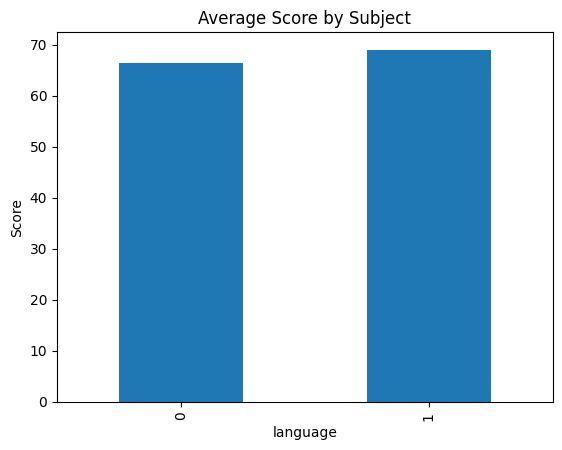

In [214]:
df2.groupby("language")["score"].mean().plot(kind="bar")
plt.title("Average Score by Subject")
plt.ylabel("Score")
plt.show()